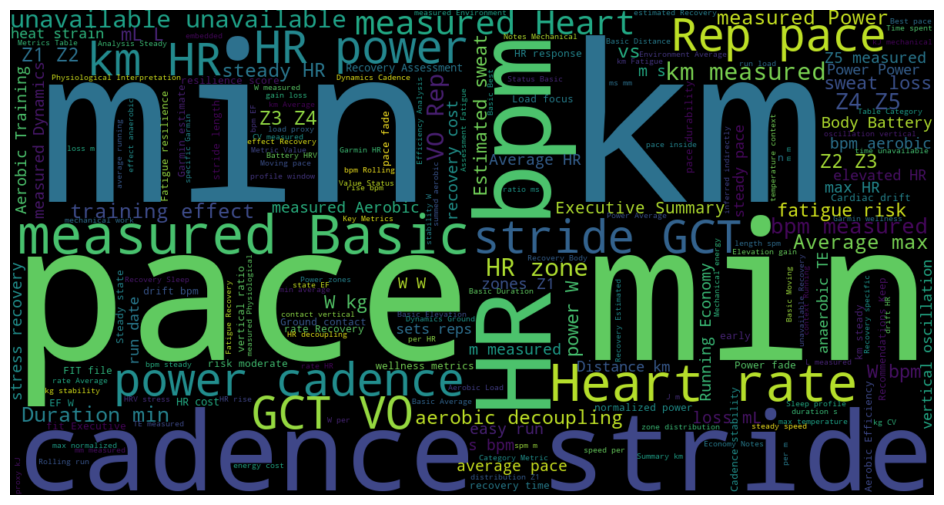

In [1]:
# Libraries
from pathlib import Path
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Read report text from the repository reports folder
cwd = Path.cwd()
# allowed_extensions = {".md", ".csv", ".txt"}
allowed_extensions = {".md"}

candidate_reports_dirs = [
    cwd / "reports",
    cwd.parent / "reports",
]

def has_allowed_files(folder: Path) -> bool:
    return folder.exists() and any(
        p.is_file() and p.suffix.lower() in allowed_extensions for p in folder.rglob("*")
    )

reports_dir = next((p for p in candidate_reports_dirs if has_allowed_files(p)), None)
if reports_dir is None:
    raise FileNotFoundError(
        f"Could not find a reports folder with {sorted(allowed_extensions)} from {cwd}"
    )

text_chunks = []
for file_path in reports_dir.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in allowed_extensions:
        text_chunks.append(file_path.read_text(encoding="utf-8", errors="ignore"))

text = "\n".join(text_chunks).strip()
if not text:
    raise ValueError(
        f"No readable text found under {reports_dir} for extensions {sorted(allowed_extensions)}"
    )

# Create the wordcloud object
wordcloud = WordCloud(width=1200, height=630, margin=0).generate(text)

# Display the generated image
plt.figure(figsize=(12, 6.3))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()